# Session 2: Standard scRNAseq pipeline
# Part 1

In [ ]:
# —— RUN THIS BEFORE ANYTHING ELSE ———————————————————————————————
import sys
IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    from google.colab import drive; drive.mount('/content/drive')
    %run /content/drive/MyDrive/immerge_workshop/codes/notebooks/setup_notebook.py

## Configuration

In [1]:
import warnings
warnings.filterwarnings("ignore")

import gc
import glob as glob_mod
import os
import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
import anndata as ad
import scanpy as sc
import scvi
import seaborn as sns
from anndata.experimental import concat_on_disk

sc.settings.verbosity = 3
sc.set_figure_params(dpi=100, frameon=False, figsize=(6, 5))
ad.settings.allow_write_nullable_strings = True

# —— DIRECTORIES —————————————————————————————————————————————————
MAIN_DIR = "/nfs/team292/projects/immerge_workshop/"
DATA_DIR = os.path.join(MAIN_DIR, "data/")
OUT_DIR = os.path.join(MAIN_DIR, "results/temp/session2_part1/")

os.makedirs(OUT_DIR, exist_ok=True)

# —— INPUT FILES —————————————————————————————————————————————————
DATASETS = {
    "Burns": os.path.join(DATA_DIR, "burns_f_2026.h5ad"),
    "Wang": os.path.join(DATA_DIR, "wang_f_2020.h5ad"),
}

DATASET = "" # To be replaced by Luz's concatenated object

## 1) Loading the dataset
First we are going to load our dataset:

In [2]:
# TO be removed
# —— READ EACH OBJECT INTO A DICTIONARY ——————————————————————————
adatas = {}

for k, v in DATASETS.items():
    print(f"Loading {k} dataset...")
    adatas[k] = sc.read_h5ad(v)
    print(adatas[k])
    
# —— CONCATENATE ALONG THE CELL AXIS —————————————————————————————
adata = ad.concat(
    list(adatas.values()),
    axis=0,
    join="inner"
)

Loading Burns dataset...
AnnData object with n_obs × n_vars = 35930 × 31280
    obs: 'n_genes', 'percent_mito', 'doublet_scores', 'senescence_score', 'stress_score_vandenBrink', 'health_score', 'metabolic_activity', 'S_score', 'G2M_score', 'phase', 'sample', 'dataset', 'in_HCAv1', 'exclusion-inclusion_criteria', 'Organ', 'Dataset', 'Sample_id', 'Library_id', 'Donor_id', 'Sex', 'Postnatal_age_years', 'Gestational_age_pcw', 'Developmental_stage', 'Tanner Stage', 'Menstrual_stage', 'Disease', 'Clinical_diagnosis', 'Organ_part', 'Tissue_ROI', 'Specimen_type', 'Sampled_site_condition', 'Observed_pathology', 'Tissue_status', 'Dissociation_method', 'Cell_enrichment', 'Preservation_method', 'Target_cell_population', 'Sorting_method', 'Assay_type', 'Library_chemistry', 'Sequencing_platform', 'Multiplexed', 'Dataset_id', 'Batch', 'Collection_site', 'Sample_id_other', 'Menstrual_stage_OriginalAuthors'
Loading Wang dataset...
AnnData object with n_obs × n_vars = 25971 × 32483
    obs: 'n_genes', '

In [91]:
#adata = sc.read_h5ad(DATASET)

AnnData object with n_obs × n_vars = 61901 × 30926
    obs: 'n_genes', 'percent_mito', 'doublet_scores', 'senescence_score', 'stress_score_vandenBrink', 'health_score', 'metabolic_activity', 'S_score', 'G2M_score', 'phase', 'sample', 'dataset', 'in_HCAv1', 'exclusion-inclusion_criteria', 'Organ', 'Dataset', 'Sample_id', 'Library_id', 'Donor_id', 'Sex', 'Postnatal_age_years', 'Gestational_age_pcw', 'Developmental_stage', 'Tanner Stage', 'Menstrual_stage', 'Disease', 'Clinical_diagnosis', 'Organ_part', 'Tissue_ROI', 'Specimen_type', 'Sampled_site_condition', 'Observed_pathology', 'Tissue_status', 'Dissociation_method', 'Cell_enrichment', 'Preservation_method', 'Target_cell_population', 'Sorting_method', 'Assay_type', 'Library_chemistry', 'Sequencing_platform', 'Multiplexed', 'Dataset_id', 'Batch', 'Collection_site', 'Sample_id_other', 'Menstrual_stage_OriginalAuthors'

## 2) Exploring the raw dataset

> ### ✏️ Exercise 1 — How many cells and genes do we have in our dataset?
>
> Print the **shape** of your gene expression matrix.
>

<details>
<summary><i>Show solution</i></summary>

```python
print(adata.shape)   
```
    
We have 61901 cells and 30926 genes.

</details>

Let's print the first 10 rows and columns of our gene expression matrix, do we have raw counts/integers on the matrix?

In [3]:
adata.X[:10, :10].toarray()

array([[ 0.,  0.,  0.,  0.,  0.,  0.,  1.,  0.,  7.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  4.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  1.,  0.,  9.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  6.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  2.,  0., 11.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  1.,  0.,  4.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  1.,  0.,  2.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  3.,  0.,  4.,  0.],
       [ 1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  3.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  2.,  0.,  3.,  0.]], dtype=float32)

What is the minimum number of counts we have in the matrix?

In [4]:
adata.X.min()

np.float32(0.0)

And the maximum?

In [5]:
adata.X.max()

np.float32(14126.0)

Now let's make a histogram of all the expression values in our matrix. Which number is the most frequently found in the matrix?

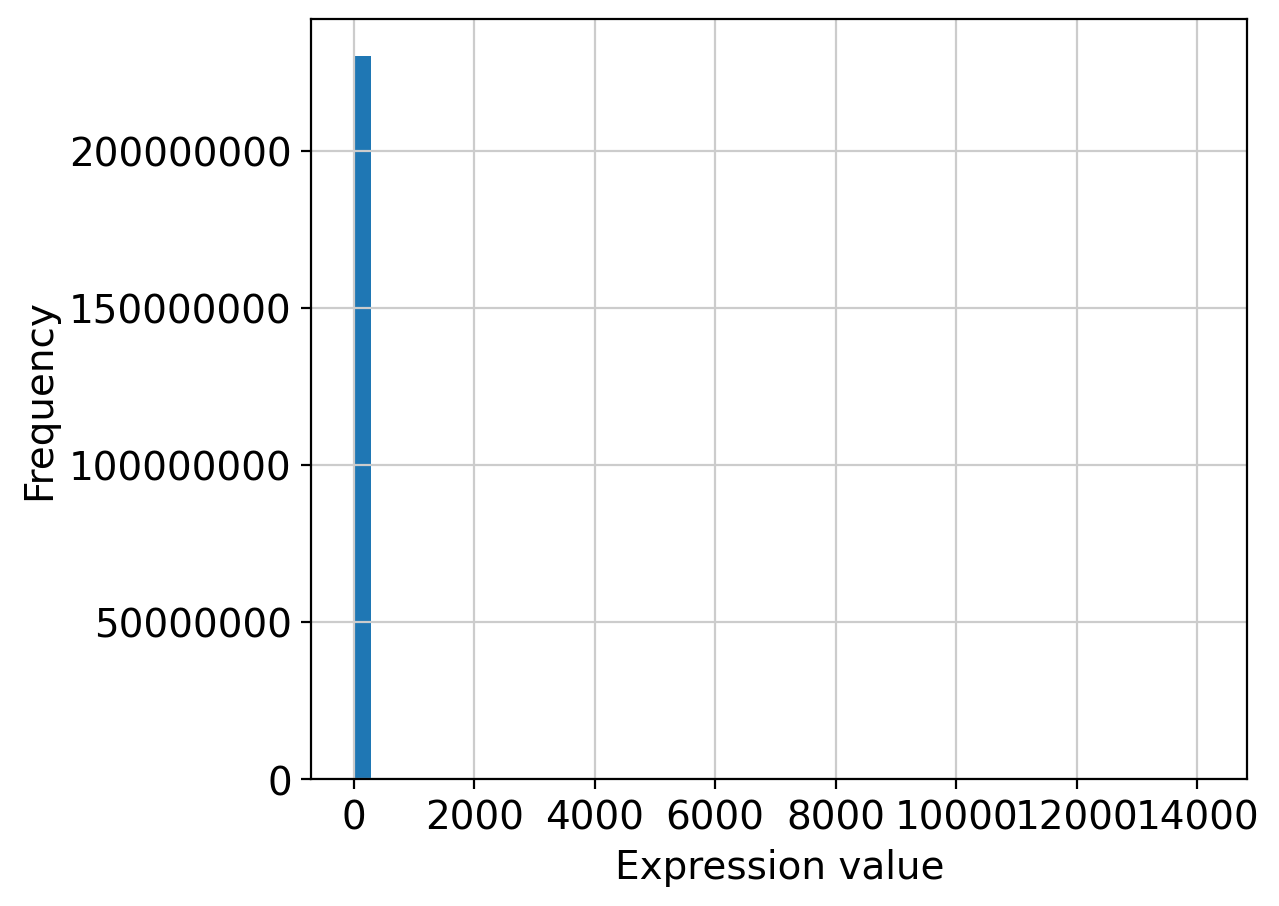

In [6]:
plt.hist(adata.X.data, bins=50, log=False)
plt.ticklabel_format(style='plain', axis='y')
plt.xlabel("Expression value")
plt.ylabel("Frequency")
plt.show()

Let's set log=True:

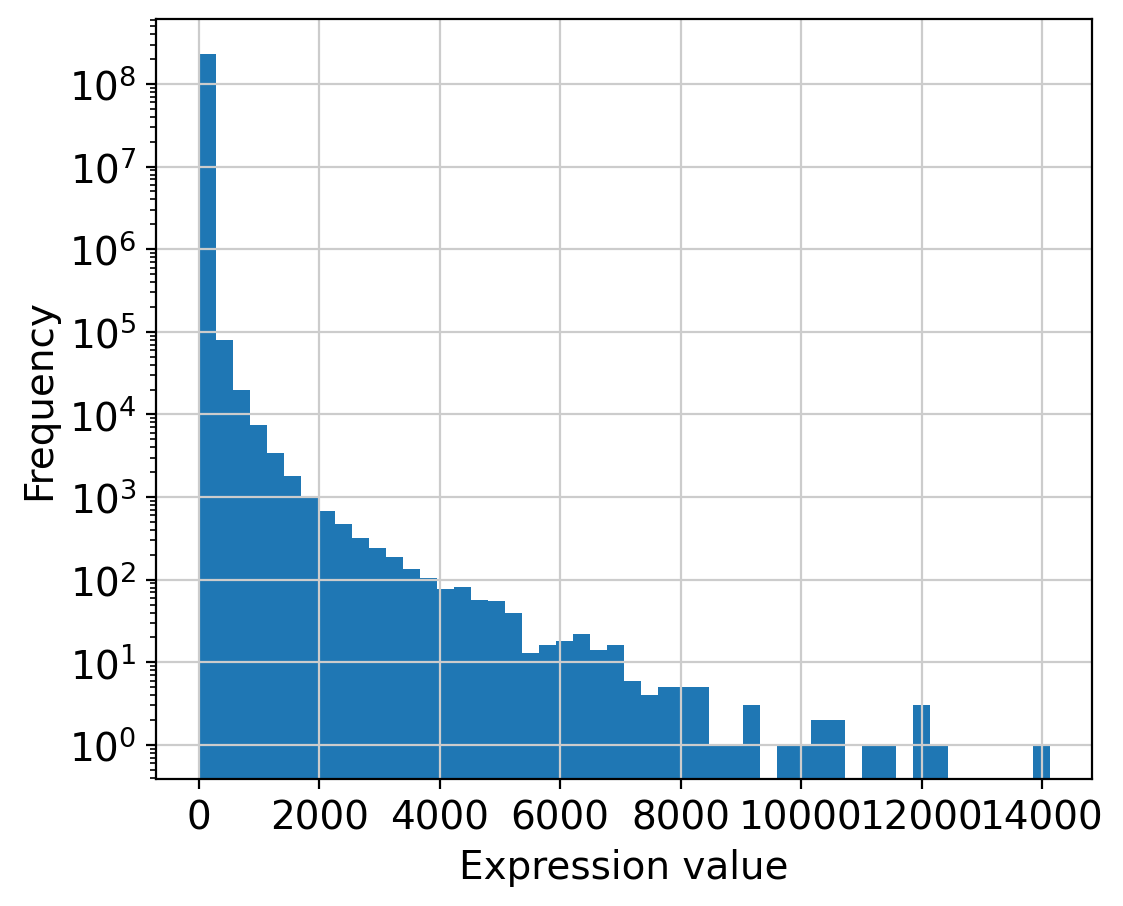

In [7]:
plt.hist(adata.X.data, bins=50, log=True)
plt.xlabel("Expression value")
plt.ylabel("Frequency")
plt.show()

Now let's check the percentage of genes in each cell for which the gene expression value is different from 0:

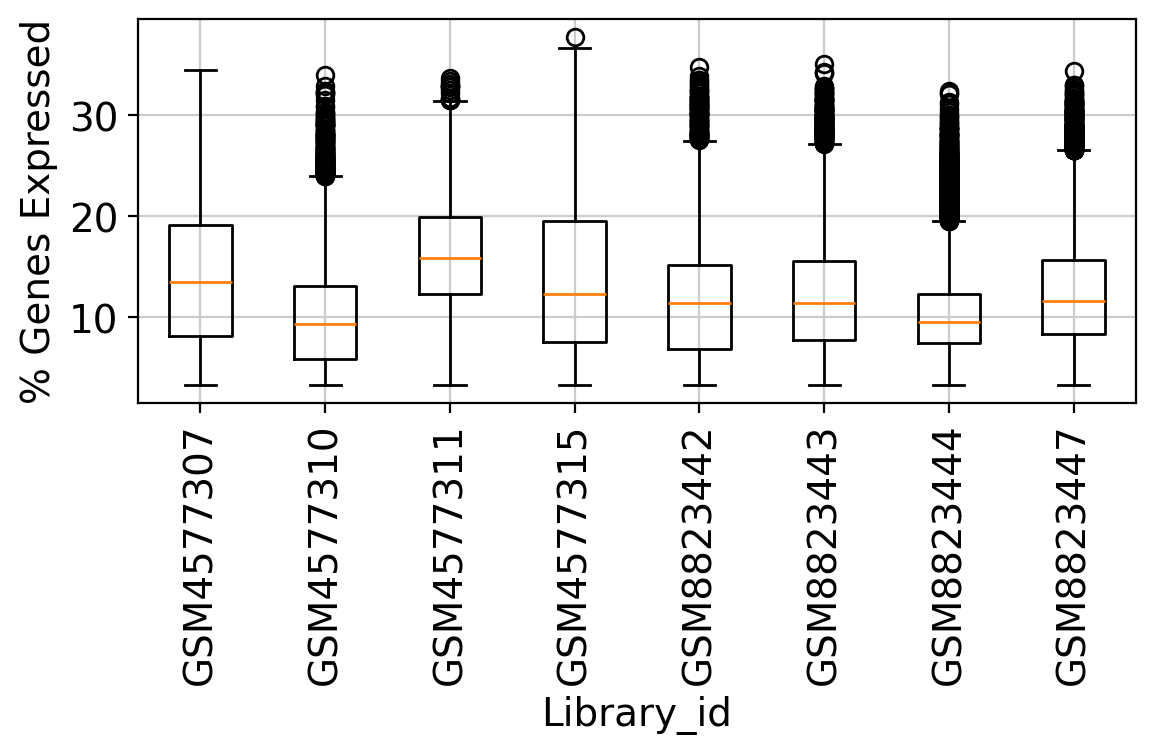

Library_id
GSM4577307    13.467632
GSM4577310     9.331954
GSM4577311    15.912177
GSM4577315    12.329432
GSM8823442    11.385242
GSM8823443    11.401410
GSM8823444     9.561534
GSM8823447    11.614822
Name: pct_genes_expressed, dtype: float64

In [16]:
adata.obs["pct_genes_expressed"] = (adata.obs["n_genes"] / adata.n_vars) * 100

# One box per library
groups = adata.obs.groupby("Library_id", observed=True)["pct_genes_expressed"]
labels = list(groups.groups.keys())
data = [groups.get_group(g).values for g in labels]

fig, ax = plt.subplots(figsize=(max(6, 0.5 * len(labels)), 4))
ax.boxplot(data, labels=labels)
ax.set_ylabel("% Genes Expressed")
ax.set_xlabel("Library_id")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Median per library
adata.obs.groupby("Library_id", observed=True)["pct_genes_expressed"].median()

## 3) Quality control
We would like to plot:

- Number of genes expressed per cell
- Number of counts per cell
- Proportion of mitochondrial reads per cell
- Doublet scores

We first need to identify which genes are mitochondrial genes.

In [17]:
# mitochondrial genes start with "MT-" for human
adata.var["mt"] = np.asarray(adata.var_names.str.startswith("MT-"), dtype=bool)
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], inplace=True, log1p=True)

In [18]:
adata

AnnData object with n_obs × n_vars = 61724 × 30926
    obs: 'n_genes', 'percent_mito', 'doublet_scores', 'senescence_score', 'stress_score_vandenBrink', 'health_score', 'metabolic_activity', 'S_score', 'G2M_score', 'phase', 'sample', 'dataset', 'in_HCAv1', 'exclusion-inclusion_criteria', 'Organ', 'Dataset', 'Sample_id', 'Library_id', 'Donor_id', 'Sex', 'Postnatal_age_years', 'Gestational_age_pcw', 'Developmental_stage', 'Tanner Stage', 'Menstrual_stage', 'Disease', 'Clinical_diagnosis', 'Organ_part', 'Tissue_ROI', 'Specimen_type', 'Sampled_site_condition', 'Observed_pathology', 'Tissue_status', 'Dissociation_method', 'Cell_enrichment', 'Preservation_method', 'Target_cell_population', 'Sorting_method', 'Assay_type', 'Library_chemistry', 'Sequencing_platform', 'Multiplexed', 'Dataset_id', 'Batch', 'Collection_site', 'Sample_id_other', 'Menstrual_stage_OriginalAuthors', 'pct_genes_expressed', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts

Now let's plot these variables per library:

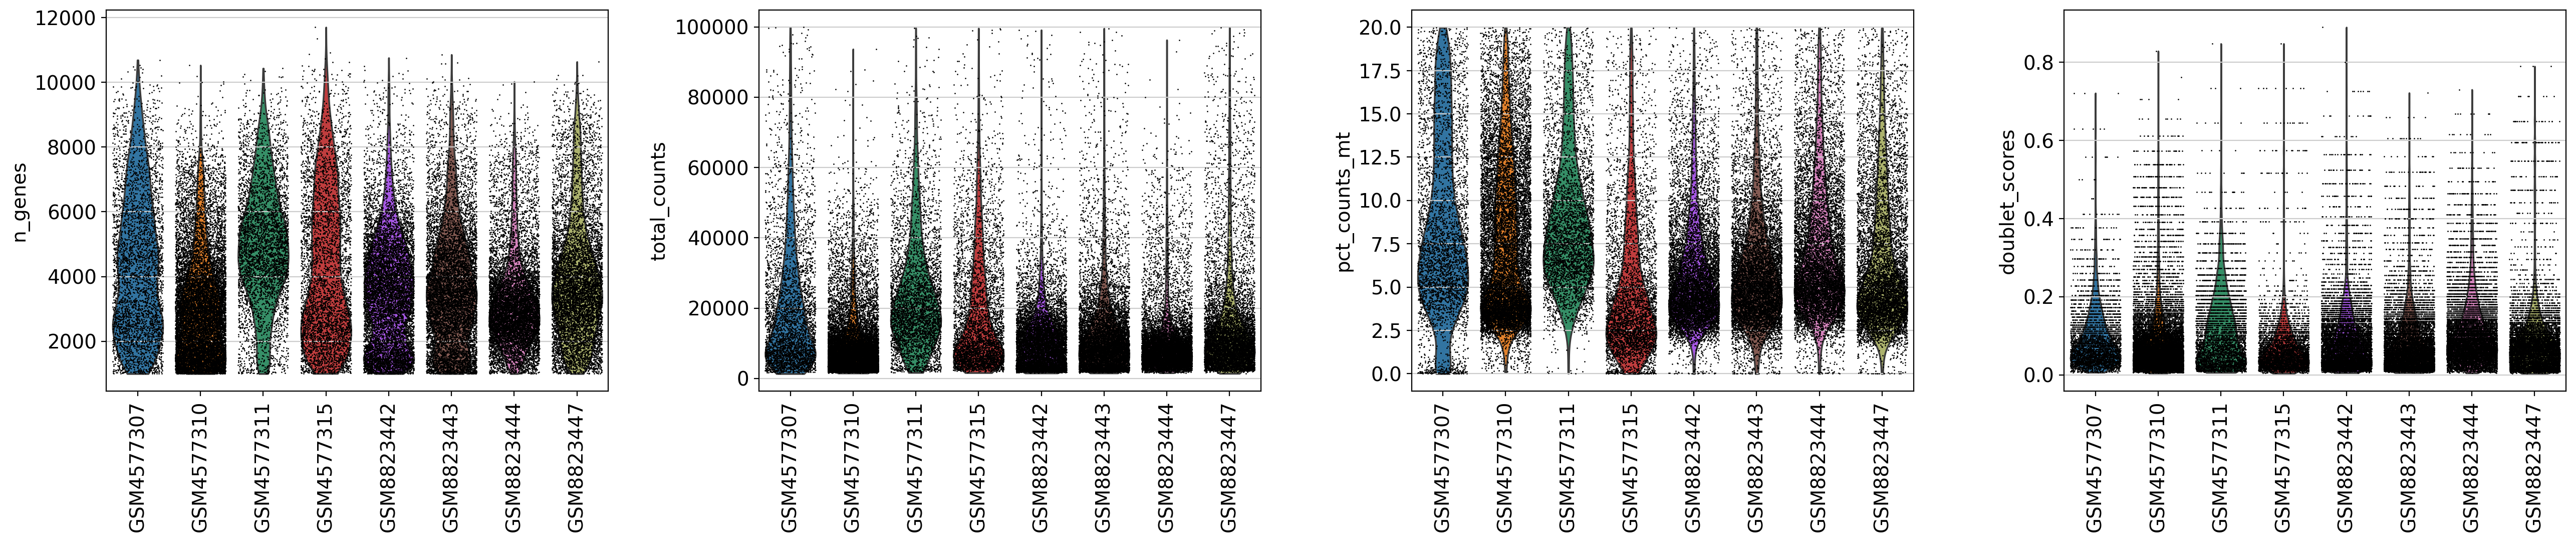

In [19]:
# —— VIOLIN PLOTS PER LIBRARY ————————————————————————————————————
sc.pl.violin(
    adata,
    keys=["n_genes", "total_counts", "pct_counts_mt", "doublet_scores"],
    groupby="Library_id",
    jitter=0.4,
    multi_panel=True,
    rotation=90,
)

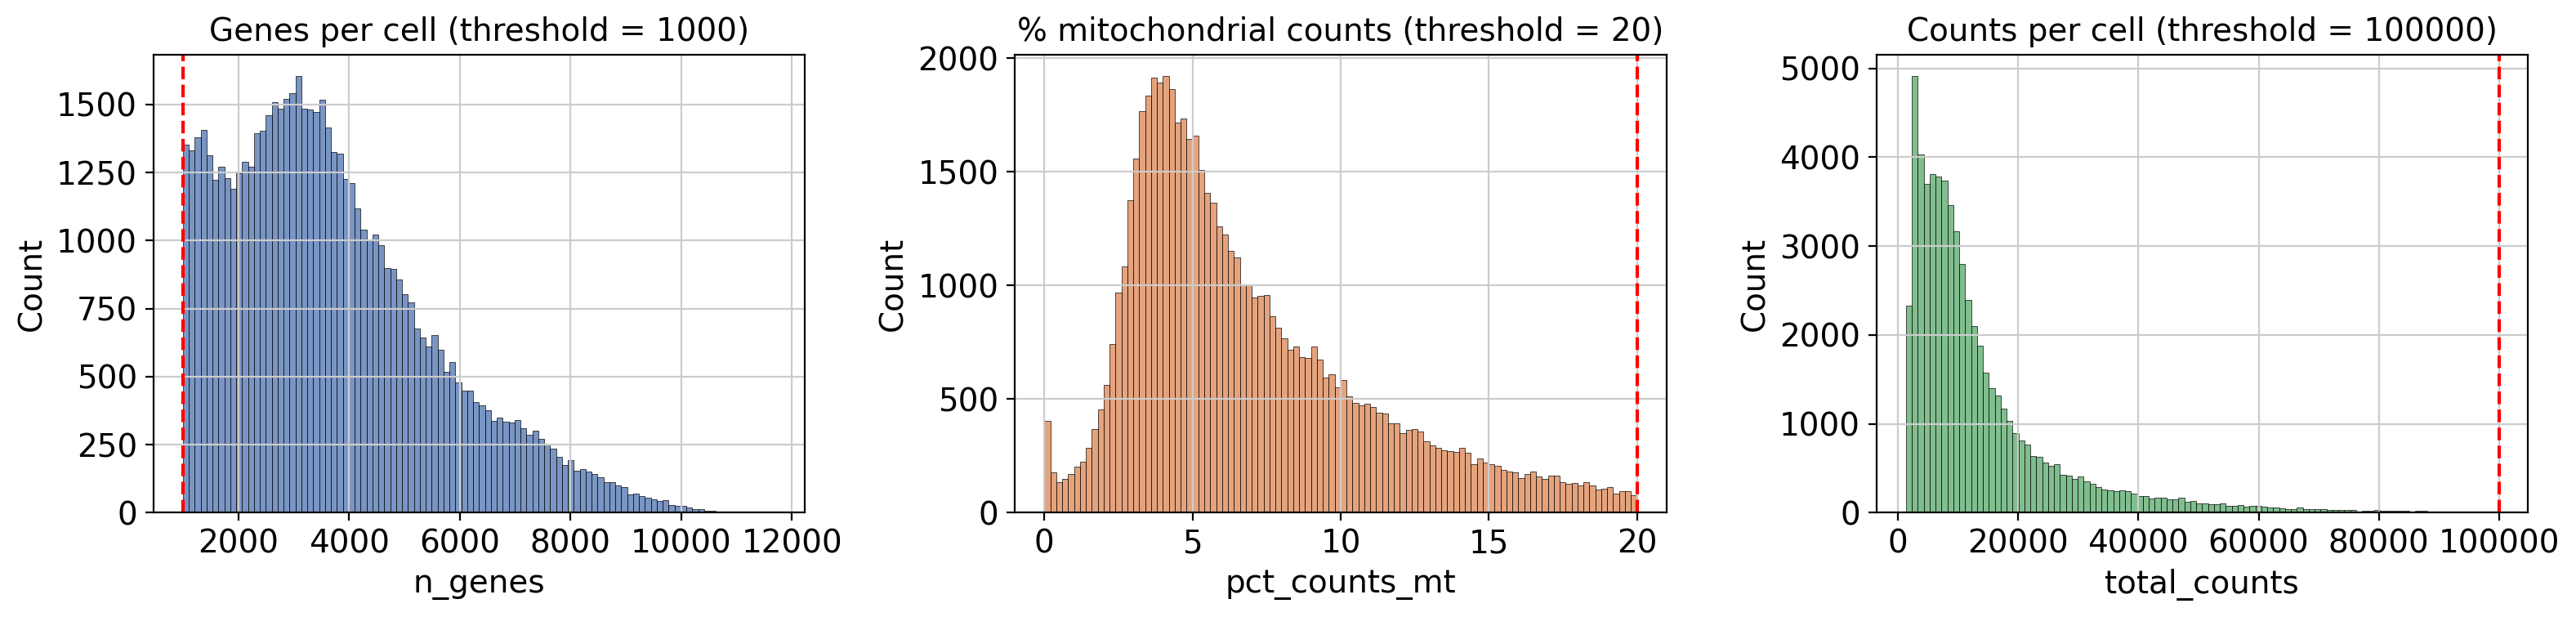

In [20]:
MIN_GENES=1000
MAX_COUNTS=100000
MAX_PCT_MITO=20

# —— HISTOGRAMS WITH THRESHOLDS MARKED ———————————————————————————
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Left panel: number of genes per cell.
sns.histplot(adata.obs["n_genes"], bins=100, ax=axes[0], color="#4C72B0")
axes[0].axvline(MIN_GENES, color="red", linestyle="--")
axes[0].set_title(f"Genes per cell (threshold = {MIN_GENES})")
axes[0].set_xlabel("n_genes")

# Mid panel: mitochondrial percentage per cell.
sns.histplot(adata.obs["pct_counts_mt"], bins=100, ax=axes[1], color="#DD8452")
axes[1].axvline(MAX_PCT_MITO, color="red", linestyle="--")
axes[1].set_title(f"% mitochondrial counts (threshold = {MAX_PCT_MITO})")
axes[1].set_xlabel("pct_counts_mt")

# Right panel: number of counts per cell.
sns.histplot(adata.obs["total_counts"], bins=100, ax=axes[2], color="#55A868")
axes[2].axvline(MAX_COUNTS, color="red", linestyle="--")
axes[2].set_title(f"Counts per cell (threshold = {MAX_COUNTS})")
axes[2].set_xlabel("total_counts")

plt.tight_layout()
plt.show()

What are good cutoffs?

In [21]:
adata = adata[(adata.obs["n_genes"] >= MIN_GENES) & (adata.obs["pct_counts_mt"] < MAX_PCT_MITO) & (adata.obs["total_counts"] < MAX_COUNTS)]

> ### ✏️ Exercise 2 — How many cells do we have now in our dataset?
>
> Print the **shape** of your gene expression matrix.
>

<details>
<summary><i>Show solution</i></summary>

```python
print(adata.shape)      
```
    
We now have 61724 cells.

</details>

## 4) Data normalization
We first need to store the raw counts on a different slot, we will call it "counts".

In [22]:
adata.layers["counts"] = adata.X.copy()

In [23]:
adata.layers["counts"][:10, :10].toarray()

array([[ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  3.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  4.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0., 10.,  0.],
       [ 1.,  0.,  0., 22.,  0.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  5.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,  0.]], dtype=float32)

Now we perform library size normalization.

In [24]:
sc.pp.normalize_total(adata, target_sum=1e4)

normalizing counts per cell
    finished (0:00:02)


How does it look like?

In [25]:
adata.X[:10, :10].toarray()

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.30279174, 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.4047477 , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.10234262, 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.10249262, 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.10349502, 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 1.0520004 , 0.        ],
       [0.10535965, 0.        , 0.        , 2.3179123 , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.       

Now let's log transform the data.

In [26]:
sc.pp.log1p(adata)

How does it look like?

In [27]:
adata.X[:10, :10].toarray()

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.26450944, 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.3398577 , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.09743757, 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.09757364, 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.09848244, 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.71881515, 0.        ],
       [0.10017076, 0.        , 0.        , 1.1993358 , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.       

> ### ✏️ Exercise 3 — Let's now make the same histogram of expression values as before, do you see any changes?
> Set log=False

<details>
<summary><i>Show solution</i></summary>

```python
plt.hist(adata.X.data, bins=50, log=False)
plt.ticklabel_format(style='plain', axis='y')
plt.xlabel("Normalized expression value")
plt.ylabel("Frequency")
plt.show() 
```

</details>

## 5) Feature selection - Highly variable genes
Let's identify the top 2000 highly variable genes.

In [33]:
sc.pp.highly_variable_genes(
    adata,
    n_top_genes=3000,
    flavor="seurat_v3",
    layer="counts",
    batch_key="Dataset",
    subset=False,         # keep all genes in the object
)

extracting highly variable genes
--> added
    'highly_variable', boolean vector (adata.var)
    'highly_variable_rank', float vector (adata.var)
    'means', float vector (adata.var)
    'variances', float vector (adata.var)
    'variances_norm', float vector (adata.var)


Where are they stored?

In [29]:
adata.var

,mt,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts,highly_variable,highly_variable_rank,means,variances,variances_norm
A1BG,False,8869,0.183024,0.168074,85.631197,11297.0,9.332381,False,NaN,0.183024,0.251857,0.719284
A1BG-AS1,False,3651,0.065031,0.063004,94.084959,4014.0,8.297792,False,NaN,0.065031,0.074510,0.662485
A1CF,False,47,0.000826,0.000826,99.923855,51.0,3.951244,False,NaN,0.000826,0.000955,1.039130
A2M,False,8562,0.707861,0.535242,86.128572,43692.0,10.684943,True,51.0,0.707861,29.573451,13.741374
A2M-AS1,False,1186,0.020608,0.020398,98.078543,1272.0,7.149132,False,NaN,0.020608,0.023132,0.749245
...,...,...,...,...,...,...,...,...,...,...,...,...
ZXDC,False,20679,0.529259,0.424783,66.497635,32668.0,10.394182,False,NaN,0.529259,0.935796,0.675283
ZYG11A,False,730,0.015180,0.015066,98.817316,937.0,6.843750,False,NaN,0.015180,0.027004,1.238894
ZYG11B,False,21265,0.567915,0.449747,65.548247,35054.0,10.464674,False,NaN,0.567915,1.023383,0.665293
ZYX,False,29879,1.039288,0.712601,51.592573,64149.0,11.068979,False,NaN,1.039288,2.475993,0.621310


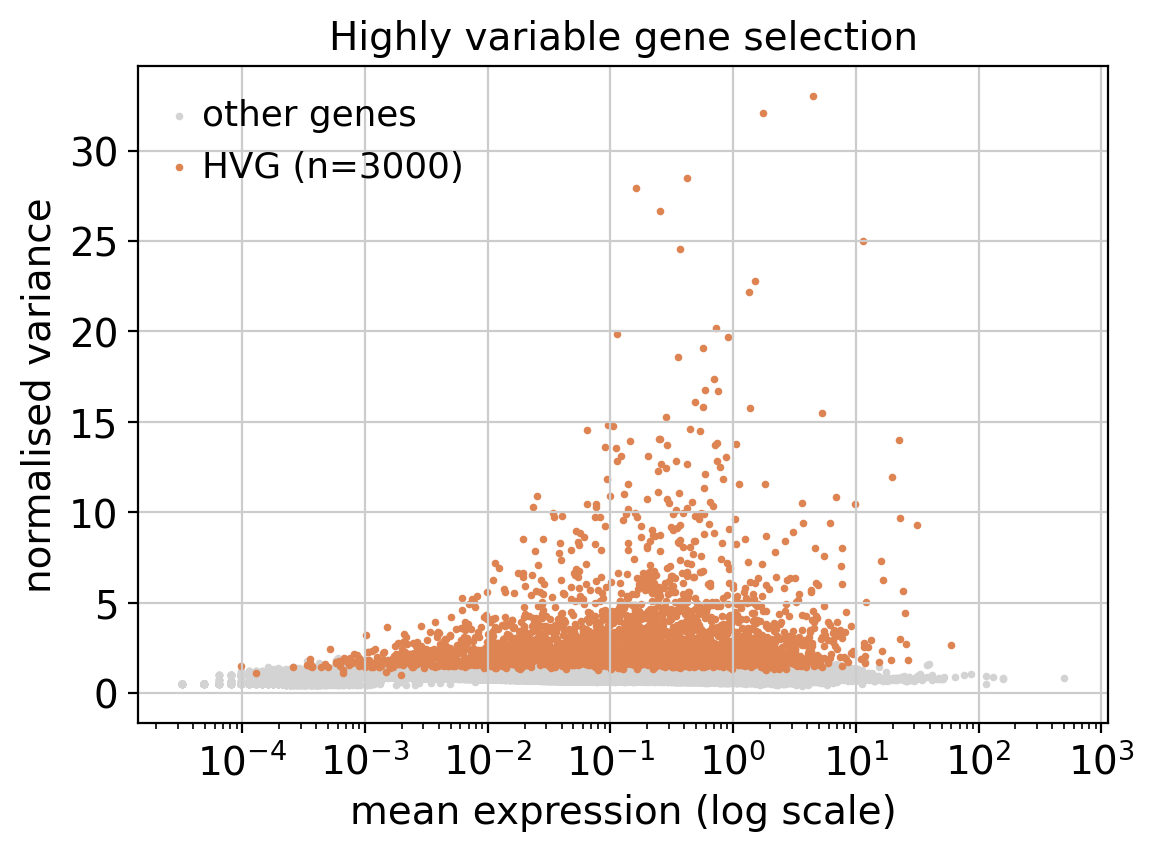

In [34]:
# —— PLOT MEAN VS NORMALISED VARIANCE ————————————————————————————
hv = adata.var["highly_variable"].values

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.scatter(adata.var.loc[~hv, "means"], adata.var.loc[~hv, "variances_norm"],
           s=3, c="lightgrey", label="other genes")
ax.scatter(adata.var.loc[hv, "means"], adata.var.loc[hv, "variances_norm"],
           s=3, c="#DD8452", label=f"HVG (n={hv.sum()})")
ax.set_xscale("log")                     # mean expression spans orders of magnitude
ax.set_xlabel("mean expression (log scale)")
ax.set_ylabel("normalised variance")
ax.legend(frameon=False)
ax.set_title("Highly variable gene selection")
plt.tight_layout()
plt.show()

Which are the top 10 highly variable genes?

In [35]:
top = (adata.var.loc[hv]
       .sort_values("variances_norm", ascending=False)
       .head(10)[["means", "variances_norm"]])
display(top)

,means,variances_norm
SCGB1D4,4.510660,33.043085
GNLY,1.753354,32.063235
LYZ,0.420242,28.463817
CDC20B,0.163081,27.911106
S100A9,0.253580,26.658007
PAEP,11.472166,25.021193
AL136456.1,0.370213,24.555909
XACT,1.506124,22.772478
MMP7,1.358953,22.182712
HLA-DRA,0.730332,20.179842


## 6) Saving the object
Finally, let's save the object.

In [116]:
adata.write_h5ad(OUT_DIR + "adata_s2part1.h5ad")